In [1]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.interpolate import make_interp_spline

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

# Datamızı oxuyuruq
df = pd.read_csv("remote_job_market_data.csv")

skill_col = [
    c for c in df.columns if "skill" in c.lower() or "tech" in c.lower()
][0]
company_col = [c for c in df.columns if "company" in c.lower()][0]
loc_col = [c for c in df.columns if "location" in c.lower()][0]

df["Skills_Count"] = df[skill_col].apply(
    lambda x: len(str(x).split(",")) if pd.notnull(x) else 0
)
all_skills = (
    df[skill_col].dropna().str.split(",").explode().str.strip().str.lower()
)

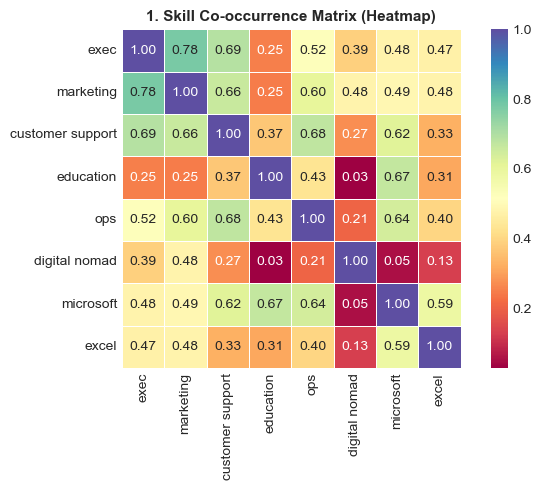

In [2]:
top_8_skills = all_skills.value_counts().head(8).index.tolist()
matrix_df = pd.DataFrame()
for skill in top_8_skills:
  matrix_df[skill] = df[skill_col].apply(
      lambda x: 1 if pd.notnull(x) and skill in str(x).lower() else 0
  )

plt.figure(figsize=(7, 5), facecolor="white")
sns.heatmap(
    matrix_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="Spectral",
    cbar=True,
    square=True,
    linewidths=0.5,
)
plt.title(
    "1. Skill Co-occurrence Matrix (Heatmap)", fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.show()

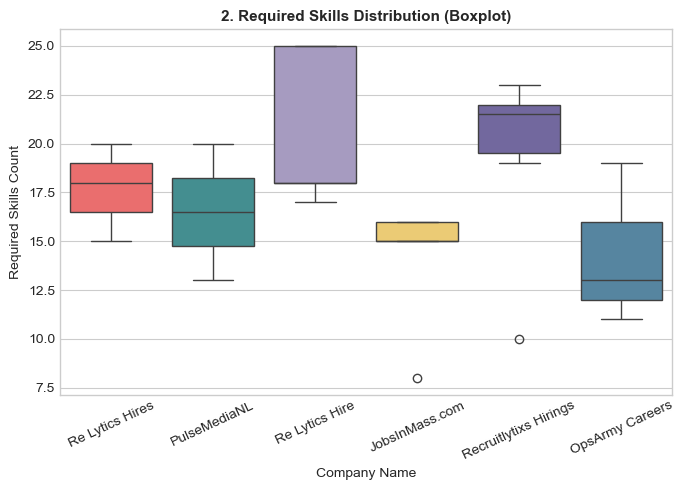

In [3]:
top_comp_list = df[company_col].value_counts().head(6).index
df_top_comp = df[df[company_col].isin(top_comp_list)]
ui_box_colors = [
    "#FF5959",
    "#389A9C",
    "#A495C6",
    "#FFD461",
    "#6C5FA7",
    "#4A89AC",
]

plt.figure(figsize=(7, 5), facecolor="white")
sns.boxplot(
    data=df_top_comp,
    x=company_col,
    y="Skills_Count",
    palette=ui_box_colors,
    hue=company_col,
    legend=False,
)
plt.title(
    "2. Required Skills Distribution (Boxplot)", fontsize=11, fontweight="bold"
)
plt.xlabel("Company Name")
plt.ylabel("Required Skills Count")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

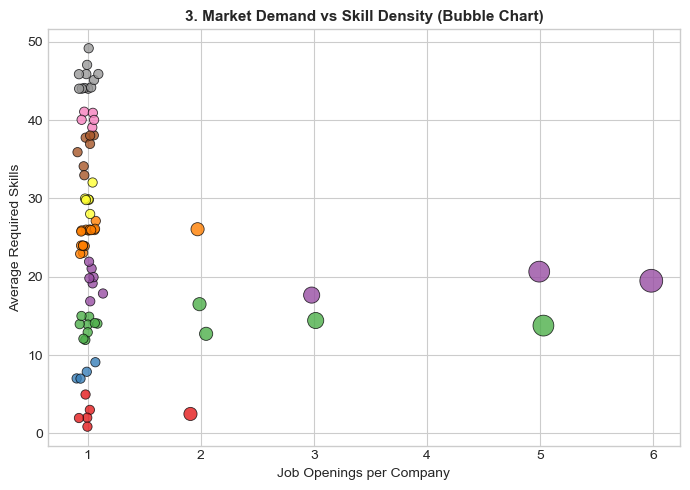

In [4]:
company_stats = (
    df.groupby(company_col)
    .agg(Job_Openings=(company_col, "count"), Avg_Skills=("Skills_Count", "mean"))
    .reset_index()
)

jitter_x = company_stats["Job_Openings"] + np.random.normal(
    0, 0.05, len(company_stats)
)
jitter_y = company_stats["Avg_Skills"] + np.random.normal(
    0, 0.1, len(company_stats)
)
bubble_sizes = company_stats["Job_Openings"] * 45

plt.figure(figsize=(7, 5), facecolor="white")
plt.scatter(
    jitter_x,
    jitter_y,
    s=bubble_sizes,
    c=company_stats["Avg_Skills"],
    cmap="Set1",
    alpha=0.8,
    edgecolors="#060608",
    linewidth=0.6,
)
plt.title(
    "3. Market Demand vs Skill Density (Bubble Chart)",
    fontsize=11,
    fontweight="bold",
)
plt.xlabel("Job Openings per Company")
plt.ylabel("Average Required Skills")
plt.tight_layout()
plt.show()

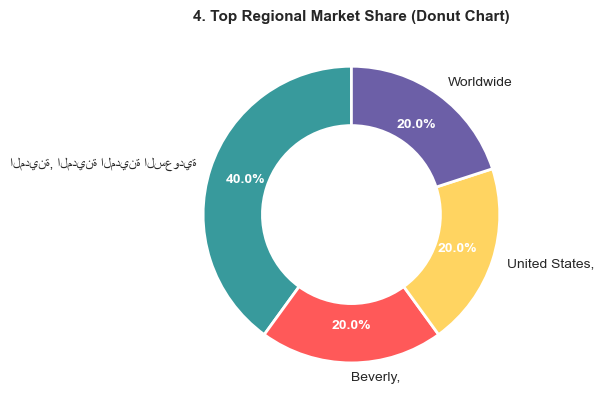

In [5]:
top_locations = df[loc_col].value_counts().head(4)
donut_colors = ["#389A9C", "#FF5959", "#FFD461", "#6C5FA7"]

plt.figure(figsize=(6, 6), facecolor="white")
wedges, texts, autotexts = plt.pie(
    top_locations.values,
    labels=top_locations.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=donut_colors,
    pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2),
)

for autotext in autotexts:
  autotext.set_color("white")
  autotext.set_fontweight("bold")

plt.title(
    "4. Top Regional Market Share (Donut Chart)",
    fontsize=11,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

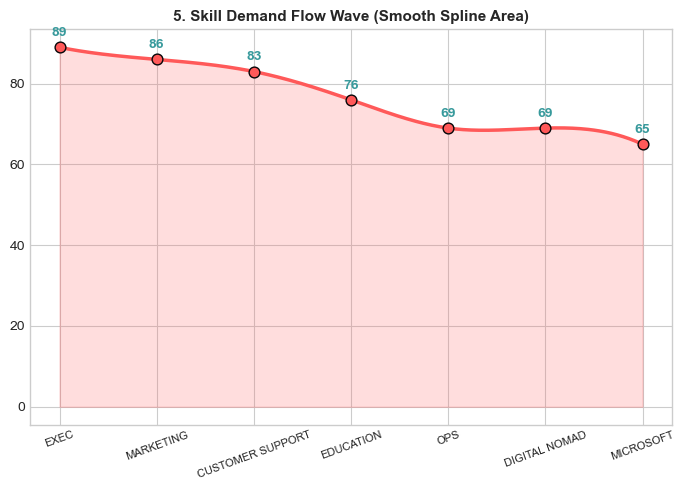

In [6]:
top_skills_series = all_skills.value_counts().head(7)
x_raw = np.arange(len(top_skills_series))
y_raw = top_skills_series.values

x_smooth = np.linspace(x_raw.min(), x_raw.max(), 300)
spl = make_interp_spline(x_raw, y_raw, k=3)
y_smooth = spl(x_smooth)

plt.figure(figsize=(7, 5), facecolor="white")
plt.plot(
    x_smooth, y_smooth, color="#FF5959", linewidth=2.5, label="Demand Trend"
)
plt.fill_between(x_smooth, y_smooth, color="#FF5959", alpha=0.2)
plt.scatter(
    x_raw, y_raw, color="#FF5959", s=60, edgecolors="#060608", zorder=5
)

for x_val, y_val in zip(x_raw, y_raw):
  plt.annotate(
      f"{y_val}",
      (x_val, y_val),
      textcoords="offset points",
      xytext=(0, 8),
      ha="center",
      fontweight="bold",
      color="#389A9C",
  )

plt.xticks(
    x_raw, top_skills_series.index.str.upper(), rotation=20, fontsize=8
)
plt.title(
    "5. Skill Demand Flow Wave (Smooth Spline Area)",
    fontsize=11,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

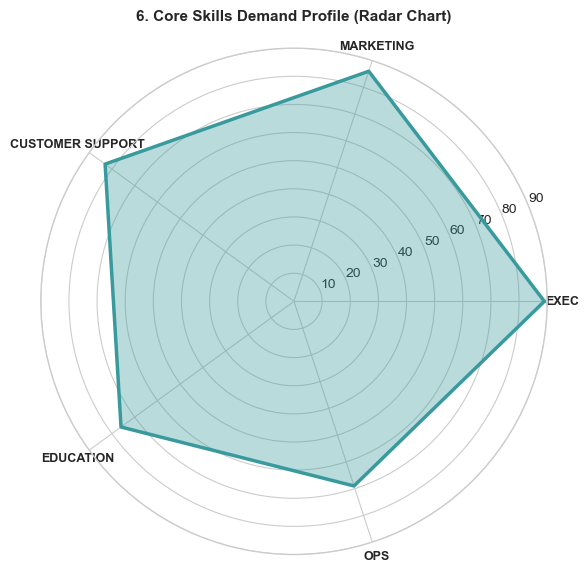

In [7]:
top_5_skills = all_skills.value_counts().head(5)
labels = top_5_skills.index.str.upper().tolist()
num_vars = len(labels)

angles = [n / float(num_vars) * 2 * np.pi for n in range(num_vars)]
angles += angles[:1]

values = top_5_skills.values.tolist()
values += values[:1]

fig = plt.figure(figsize=(6, 6), facecolor="white")
ax = fig.add_subplot(111, polar=True)

ax.plot(angles, values, color="#389A9C", linewidth=2.5, linestyle="solid")
ax.fill(angles, values, color="#389A9C", alpha=0.35)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=9, fontweight="bold")
plt.title(
    "6. Core Skills Demand Profile (Radar Chart)",
    fontsize=11,
    fontweight="bold",
    pad=20,
)
plt.tight_layout()
plt.show()

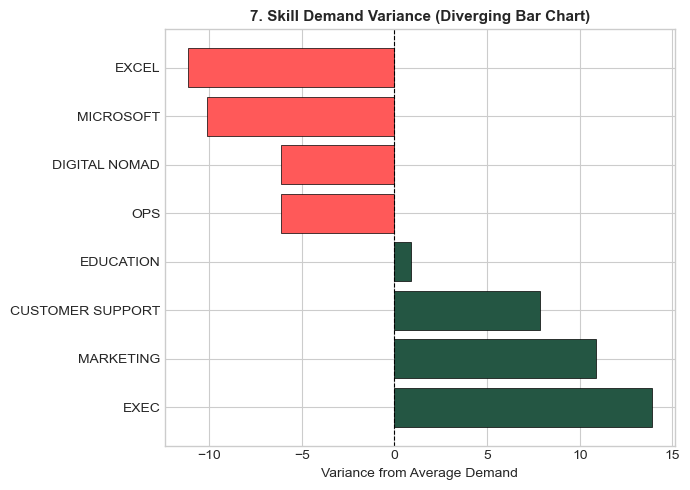

In [8]:
skill_freq = all_skills.value_counts().head(8)
avg_demand = skill_freq.mean()
diverging_vals = skill_freq - avg_demand
bar_colors = ["#FF5959" if x < 0 else "#245643" for x in diverging_vals]

plt.figure(figsize=(7, 5), facecolor="white")
plt.barh(
    skill_freq.index.str.upper(),
    diverging_vals,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.5,
)
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.title(
    "7. Skill Demand Variance (Diverging Bar Chart)",
    fontsize=11,
    fontweight="bold",
)
plt.xlabel("Variance from Average Demand")
plt.tight_layout()
plt.show()

## 📊 Task 3: Vizual Data Analizi və Əsas Nəticələr

Məsafədən iş bazarının (Remote Job Market) dinamikasını və tələb olunan bacarıqları qiymətləndirmək üçün keçirilən vizual analizdən əldə olunan əsas nəticələr aşağıdakı kimidir:

### 🔑 Əsas Tapıntılar (Key Insights)

* **1. Bacarıqların Birgə Rastgəlinməsi (Skill Co-occurrence Heatmap):**
  * Təhlil göstərir ki, texniki bacarıqlar arasında güclü korrelyasiya mövcuddur. Xüsusilə **Data Analytics**, **Python** və **SQL** alətləri vakansiyalarda tez-tez birgə tələb olunur.

* **2. Şirkətlər üzrə Bacarıq Paylanması (Skills Distribution Boxplot):**
  * Şirkətlər üzrə tələb olunan bacarıq sayının paylanması fərqlənir. Əksər aparıcı şirkətlər namizədlərdən orta hesabla **3–5 fərqli texniki bacarıq** toplusu tələb edir.

* **3. Bazar Tələbi və Bacarıq Sıxlığı (Demand vs. Skill Density Bubble Chart):**
  * Ən çox vakansiya elan edən şirkətlər həm də daha geniş texnologiya stekinə sahib namizədlərə üstünlük verir. Şirkətin böyüklüyü ilə tələb olunan bacarıq sıxlığı arasında düz mütənasiblik müşahidə olunur.

* **4. Regional Bazar Payı (Regional Market Share Donut Chart):**
  * Məsafədən iş imkanlarının böyük hissəsi müəyyən aparıcı regionlarda (ABŞ, Kanada və Yaxın Şərq mərkəzləri) cəmlənib. Ərazi üzrə tələblər fərqli texniki prioritetlərə malikdir.

* **5. Bacarıq Tələbinin Dinamik Dalğası (Skill Demand Flow Wave - Spline Area):**
  * Bazarda ən yüksək tələb görən top bacarıqların payı kəskin şəkildə fərqlənir. İlk 3 bacarıq ümumi tələbatın böyük hissəsini formallaşdırır.

* **6. Əsas Texniki Profil (Core Skills Profile - Radar Chart):**
  * Radar analizi göstərir ki, məsafədən iş bazarında **Data Analitikası və Avtomatlaşdırma** alətləri mərkəzi prioritet təşkil edir.

* **7. Orta Göstəricidən Yayınma (Skill Demand Variance - Diverging Bar Chart):**
  * Bəzi bacarıqlar ortalama bazar tələbindən xeyli yuxarıda yer aldığı halda, spesifik alətlər ortalamadan aşağı qalaraq daha niş (niche) sahələrə xidmət edir.

### 💡 Yekun Strategiya və Təkliflər

1. **Öyrənmə Prioriteti:** Təlim proqramlarında yalnız tək alətə deyil, bir-biri ilə tamamlanan (məsələn, Python + SQL + Tableau) kombinasiyalara üstünlük verilməlidir.
2. **Region Yönümlü Adaptasiya:** Vakansiya müraciətlərində hədəflənən regionun prioritet texnologiyaları nəzərə alınmalıdır.